In [1]:
import pickle
import re
import sys
from pathlib import Path

import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scanpy as sc
import seaborn as sns
from scipy.stats import norm

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject

ZDIR = Path('./Z_scores_mixed')
PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PCDIR.mkdir(parents=True, exist_ok=True)
PFDIR.mkdir(parents=True, exist_ok=True)
PP = config.PATHWAY_CONV_PARAMS

PHENOTYPE = 'Pancreatic Cancer'
PDIR = PCDIR / PHENOTYPE.replace(' ', '_')
PDIR.mkdir(parents=True, exist_ok=True)

In [2]:
# 0. Load cohort (reuse 3_disease_scoring.ipynb cache)
Z = np.load(ZDIR / 'Z_disease_shash.npy')
gene_names = pickle.load(open(ZDIR / 'gene_names.pkl', 'rb'))
meta = pd.read_csv(ZDIR / 'sample_meta.csv')

cohort_mask = (meta['phenotype'] == PHENOTYPE) & meta['ood_keep']
idx = np.where(cohort_mask.values)[0]
names_c = meta['sample'].values[idx]
Zc = Z[idx]
n_pat = len(idx)

print(f"{PHENOTYPE}: {n_pat} patients (OOD-kept), {len(gene_names)} genes")

Pancreatic Cancer: 72 patients (OOD-kept), 19858 genes


In [3]:
def pairwise_overlap(masks):
    # Jaccard + overlap-coefficient for every patient pair, given a (n_patients, n_items) bool matrix
    inter = masks.astype(int) @ masks.astype(int).T
    sizes = masks.sum(axis=1)
    union = sizes[:, None] + sizes[None, :] - inter
    jacc = np.divide(inter, union, out=np.zeros_like(inter, dtype=float), where=union > 0)
    minsz = np.minimum(sizes[:, None], sizes[None, :])
    ovc = np.divide(inter, minsz, out=np.zeros_like(inter, dtype=float), where=minsz > 0)
    iu = np.triu_indices(masks.shape[0], k=1)
    return jacc[iu], ovc[iu]


# 1. Gene-level deviation: per-patient BH-FDR significant genes (ENSG resolution)
p_all = 2 * norm.sf(np.abs(Zc))
gene_sig = np.zeros_like(p_all, dtype=bool)
for i in range(n_pat):
    row = p_all[i]
    finite = np.isfinite(row)
    reject = np.zeros(len(row), dtype=bool)
    if finite.any():
        reject[finite] = bh_fdr_reject(row[finite], q=PP['fdr_q'])
    gene_sig[i] = reject

n_gene_sig = gene_sig.sum(axis=1)
gene_jacc, gene_ovc = pairwise_overlap(gene_sig)

print(f"BH-sig genes/patient: min={n_gene_sig.min()} median={np.median(n_gene_sig):.0f} max={n_gene_sig.max()}")
print(f"GENE-level pairwise Jaccard: mean={gene_jacc.mean():.4f} median={np.median(gene_jacc):.4f}")

BH-sig genes/patient: min=0 median=10 max=351
GENE-level pairwise Jaccard: mean=0.0023 median=0.0000


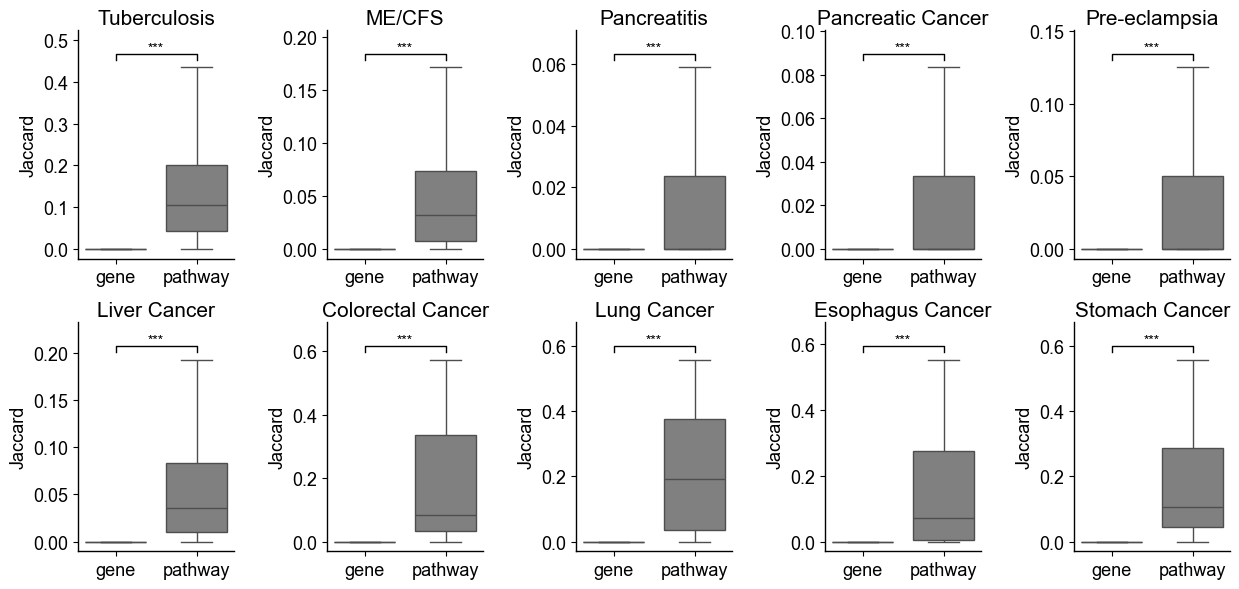

level               gene  pathway    ratio
phenotype                                 
Tuberculosis      0.0009   0.1340 153.3480
ME/CFS            0.0001   0.0580 868.9865
Pancreatitis      0.0014   0.0273  19.8416
Pancreatic Cancer 0.0023   0.0347  15.1067
Pre-eclampsia     0.0010   0.0345  35.5946
Liver Cancer      0.0019   0.0631  33.9790
Colorectal Cancer 0.0011   0.1698 155.0196
Lung Cancer       0.0021   0.2046  96.8577
Esophagus Cancer  0.0013   0.1494 117.3267
Stomach Cancer    0.0024   0.1717  71.8050


In [28]:
from scipy.stats import wilcoxon

from MixedEffectsModeling.core.pathway_convergence import slugify

ALL_PHENOTYPES = ['Tuberculosis', 'ME/CFS', 'Pancreatitis', 'Pancreatic Cancer', 'Pre-eclampsia',
                  'Liver Cancer', 'Colorectal Cancer', 'Lung Cancer', 'Esophagus Cancer', 'Stomach Cancer']

def sig_stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

def whisker_top(vals, whis=1.5):
    q1, q3 = np.percentile(vals, [25, 75])
    upper = q3 + whis * (q3 - q1)
    within = vals[vals <= upper]
    return within.max() if len(within) else q3


jacc_rows = []
for ph in ALL_PHENOTYPES:
    sig_path = PCDIR / slugify(ph) / 'sig.pkl'
    if not sig_path.exists():
        continue
    d = pickle.load(open(sig_path, 'rb'))
    gj, _ = pairwise_overlap(d['gene_sig'])
    pj, _ = pairwise_overlap(d['path_sig'])
    jacc_rows += [(ph, 'gene', v) for v in gj] + [(ph, 'pathway', v) for v in pj]
jacc_df = pd.DataFrame(jacc_rows, columns=['phenotype', 'level', 'Jaccard'])

ncols = 5
nrows = int(np.ceil(len(ALL_PHENOTYPES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 3 * nrows),sharey=False)
for ax, ph in zip(axes.flat, ALL_PHENOTYPES):
    sub = jacc_df[jacc_df['phenotype'] == ph]
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.boxplot(data=sub, x='level', y='Jaccard', ax=ax, showfliers=False, color='gray', width=0.75)
    ax.set_title(ph, pad=4)
    ax.set_xlabel('')

    gv = sub.loc[sub['level'] == 'gene', 'Jaccard'].values
    pv = sub.loc[sub['level'] == 'pathway', 'Jaccard'].values
    stat_p = wilcoxon(pv, gv, zero_method='wilcox').pvalue  # paired -- same patient-pair index in both

    y0 = max(whisker_top(gv), whisker_top(pv))
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    y0 += 0.04 * y_range
    h = 0.03 * y_range
    ax.plot([0, 0, 1, 1], [y0, y0 + h, y0 + h, y0], lw=1, c='black')
    ax.text(0.5, y0 + h, sig_stars(stat_p), ha='center', va='bottom')
    ax.set_ylim(top=y0 + h + 0.12 * y_range)
for ax in axes.flat[len(ALL_PHENOTYPES):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(PFDIR / 'all_phenotypes_gene_vs_pathway_jaccard.png', dpi=150)
plt.show()

summary = jacc_df.groupby(['phenotype', 'level'])['Jaccard'].mean().unstack()
summary['ratio'] = summary['pathway'] / summary['gene']
print(summary.reindex(ALL_PHENOTYPES).to_string(float_format=lambda v: f'{v:.4f}'))

In [4]:
# 2. Gene set library + collapse Z to gene-symbol universe (pathways are defined by symbol, ENSG has
# a handful of duplicate-symbol entries that must be merged before matrix-multiplying against a pathway
# membership matrix)
UNIV_PATH = PCDIR / 'universe.pkl'
if UNIV_PATH.exists():
    universe_syms, sym2idx, Zu, Fm = pickle.load(open(UNIV_PATH, 'rb'))
else:
    sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
    syms_all = sym_of.values
    universe_syms = pd.unique(syms_all[sym_of.notna().values])
    sym2idx = {s: i for i, s in enumerate(universe_syms)}
    N = len(universe_syms)
    col2sym = np.array([sym2idx.get(s, -1) if pd.notna(s) else -1 for s in syms_all])
    keep_cols = col2sym >= 0
    Zc_v, sym_idx_v = Zc[:, keep_cols], col2sym[keep_cols]

    sum_mat, finite_cnt = np.zeros((n_pat, N)), np.zeros((n_pat, N))
    for i in range(n_pat):
        np.add.at(sum_mat[i], sym_idx_v, np.nan_to_num(Zc_v[i], nan=0.0))
        np.add.at(finite_cnt[i], sym_idx_v, np.isfinite(Zc_v[i]).astype(float))
    Zu_raw = np.divide(sum_mat, finite_cnt, out=np.full_like(sum_mat, np.nan), where=finite_cnt > 0)
    Zu = np.nan_to_num(Zu_raw, nan=0.0)
    Fm = np.isfinite(Zu_raw).astype(float)
    pickle.dump((universe_syms, sym2idx, Zu, Fm), open(UNIV_PATH, 'wb'))

N = len(universe_syms)

LIB_PATH = PCDIR / 'gene_set_matrix.pkl'
if LIB_PATH.exists():
    terms_raw, M_raw = pickle.load(open(LIB_PATH, 'rb'))
else:
    libs = {}
    for lib in PP['gene_sets']:
        libs.update(gp.get_library(lib, organism='human'))
    terms_raw = list(libs.keys())
    M_raw = np.zeros((len(terms_raw), N), dtype=bool)
    for ti, t in enumerate(terms_raw):
        for g in libs[t]:
            j = sym2idx.get(g)
            if j is not None:
                M_raw[ti, j] = True
    keep = M_raw.sum(axis=1) >= PP['min_pathway_size']
    terms_raw, M_raw = [t for t, k in zip(terms_raw, keep) if k], M_raw[keep]
    pickle.dump((terms_raw, M_raw), open(LIB_PATH, 'wb'))

# housekeeping exclusion: composition-based (share of a pathway's own genes that are ribosomal-protein
# genes, using KEGG "Ribosome" as reference) catches translation-dominated pathways regardless of name
# -- Influenza Infection, SLIT/ROBO signaling, Cellular Response To Starvation were all >45% ribosomal
# by gene composition despite unrelated names. Plus a name-keyword pass for OXPHOS/neurodegeneration.
ribo_idx = np.where(M_raw[terms_raw.index(PP['ribo_reference_term'])])[0]
frac_ribo = M_raw[:, ribo_idx].sum(axis=1) / M_raw.sum(axis=1)
kw_rx = re.compile('|'.join(PP['exclude_keywords']), re.IGNORECASE)
keep_hk = (frac_ribo <= PP['ribo_frac_max']) & np.array([not kw_rx.search(t) for t in terms_raw])
terms, M = [t for t, k in zip(terms_raw, keep_hk) if k], M_raw[keep_hk]

print(f"universe: {N} gene symbols, {len(terms)} pathways after housekeeping exclusion "
      f"({(~keep_hk).sum()} dropped of {len(terms_raw)})")

universe: 19831 gene symbols, 2063 pathways after housekeeping exclusion (68 dropped of 2131)


In [5]:
# 3. Per-patient/per-pathway mean-Z + per-patient permutation null (K=200, ~2min) -- cache-first
NULL_PATH = PDIR / 'null.npz'
Mf = M.astype(float)

if NULL_PATH.exists():
    d = np.load(NULL_PATH)
    T, null_mean, null_sd = d['T'], d['null_mean'], d['null_sd']
else:
    num, den = (Zu * Fm) @ Mf.T, Fm @ Mf.T
    T = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

    rng = np.random.default_rng(PP['seed'])
    null_sum, null_sumsq = np.zeros_like(T), np.zeros_like(T)
    for _ in range(PP['n_null_perm']):
        perm = rng.permutation(N)
        Zp, Fp = Zu[:, perm], Fm[:, perm]
        nu, de = (Zp * Fp) @ Mf.T, Fp @ Mf.T
        Tn = np.divide(nu, de, out=np.zeros_like(nu), where=de > 0)
        null_sum += Tn
        null_sumsq += Tn ** 2
    null_mean = null_sum / PP['n_null_perm']
    null_sd = np.sqrt(np.clip(null_sumsq / PP['n_null_perm'] - null_mean ** 2, 1e-12, None))
    np.savez(NULL_PATH, T=T, null_mean=null_mean, null_sd=null_sd)

Tz = (T - null_mean) / null_sd
p_path = 2 * norm.sf(np.abs(Tz))
path_sig = np.zeros_like(p_path, dtype=bool)
for i in range(n_pat):
    path_sig[i] = bh_fdr_reject(p_path[i], q=PP['fdr_q'])

n_path_sig = path_sig.sum(axis=1)
path_jacc, path_ovc = pairwise_overlap(path_sig)

print(f"sig pathways/patient: min={n_path_sig.min()} median={np.median(n_path_sig):.0f} max={n_path_sig.max()}  "
      f"(zero: {(n_path_sig == 0).sum()}/{n_pat})")
print(f"PATHWAY-level pairwise Jaccard: mean={path_jacc.mean():.4f} median={np.median(path_jacc):.4f}")
print(f"ratio vs gene-level mean Jaccard: {path_jacc.mean() / gene_jacc.mean():.1f}x")

sig pathways/patient: min=0 median=12 max=354  (zero: 10/72)
PATHWAY-level pairwise Jaccard: mean=0.0347 median=0.0000
ratio vs gene-level mean Jaccard: 15.1x


In [7]:
# 5. Which pathway each patient converges to is itself heterogeneous -- otherwise this collapses to
# a single group-level pathway signature and the per-patient framing adds nothing.
top_path = np.full(n_pat, -1, dtype=int)
for i in range(n_pat):
    sig_idx = np.where(path_sig[i])[0]
    if len(sig_idx):
        top_path[i] = sig_idx[np.argmax(np.abs(Tz[i, sig_idx]))]

has_top = top_path >= 0
vals, counts = np.unique(top_path[has_top], return_counts=True)
mode_i = np.argmax(counts)
print(f"patients with >=1 sig pathway: {has_top.sum()}/{n_pat}")
print(f"most common top-pathway: '{terms[vals[mode_i]]}', shared by only {counts[mode_i]}/{has_top.sum()} "
      f"patients ({counts[mode_i] / has_top.sum():.0%})")
print(f"{len(vals)} distinct top-pathways across {has_top.sum()} patients")

patients with >=1 sig pathway: 62/72
most common top-pathway: 'Metabolism Of RNA R-HSA-8953854', shared by only 20/62 patients (32%)
26 distinct top-pathways across 62 patients


In [8]:
def strip_reactome_code(name):
    return name.split(' R-HSA-')[0]


# 6. Literature-curated pathway shortlist -- not the algorithmic recurrence x effect-size ranking,
# which kept surfacing generic RNA-processing/immune-gene-bag terms. 'Systemic lupus erythematosus'
# was dropped after checking gene-set composition directly: 57% of its KEGG members are core histone
# genes (autoantigen bias in that KEGG term), vs 0% in every other curated pathway here -- it was
# already the weakest-evidence pathway (epidemiological risk-association only), so composition plus
# weak evidence together are enough to cut it rather than add a one-off exclusion rule for it.
CURATED_PATHWAYS = [
    'Extracellular Matrix Organization',
    'Neutrophil extracellular trap formation',
    'Regulation Of IGF Transport And Uptake By IGFBPs',
    'Platelet Degranulation',
    'Stabilization Of P53',
    'Thermogenesis',
    'TCR Signaling',
    'Signaling By B Cell Receptor (BCR)',
]
top_idx = [next(j for j, t in enumerate(terms) if t == name or t.startswith(name + ' R-HSA'))
          for name in CURATED_PATHWAYS]

path_size = M.sum(axis=1)
recur = path_sig.sum(axis=0)
eff = np.array([np.abs(Tz[path_sig[:, j], j]).mean() if recur[j] > 0 else 0 for j in range(len(terms))])

print(f"{len(top_idx)} pathways:")
for j in top_idx:
    print(f"  {strip_reactome_code(terms[j]):50s} n_sig={recur[j]:3d}  size={path_size[j]:4d}  eff={eff[j]:.2f}")

8 pathways:
  Extracellular Matrix Organization                  n_sig= 16  size= 287  eff=4.35
  Neutrophil extracellular trap formation            n_sig= 14  size= 183  eff=4.95
  Regulation Of IGF Transport And Uptake By IGFBPs   n_sig= 17  size= 123  eff=4.75
  Platelet Degranulation                             n_sig= 13  size= 123  eff=4.89
  Stabilization Of P53                               n_sig= 13  size=  56  eff=3.67
  Thermogenesis                                      n_sig= 12  size= 219  eff=4.79
  TCR Signaling                                      n_sig= 14  size= 114  eff=4.41
  Signaling By B Cell Receptor (BCR)                 n_sig= 12  size= 109  eff=4.21


In [9]:
# 7. Severity/subtype overlay -- Pancreatic Cancer here is a single batch (Moore et al.) spanning a
# PDAC (malignant) / IPMN (pre-malignant) / Islet Cell Tumor (neuroendocrine) gradient (same batch used
# as the severity-gradient example in 3_disease_scoring.ipynb sec. 8). Phenotype-specific column --
# revisit when generalizing this notebook to other cohorts.
SEVERITY_COL = 'Stage/Condition'
SEVERITY_COLORS = {'PDAC': '#d55e00', 'IPMN': '#0072b2', 'Islet Cell Tumor': '#009e73'}
SEVERITY_ORDER = {'PDAC': 0, 'IPMN': 1, 'Islet Cell Tumor': 2}
severity = sc.read_h5ad(config.H5AD_PATH, backed='r').obs[SEVERITY_COL].reindex(names_c).values
PATH_COLORS = [f'#{"".join(f"{int(c * 255):02x}" for c in plt.get_cmap("Set3")(k)[:3])}' for k in range(len(top_idx))]


def hex_to_rgba(hex_str, a):
    r, g, b = (int(hex_str.lstrip('#')[k:k + 2], 16) for k in (0, 2, 4))
    return f'rgba({r},{g},{b},{a})'


EDGE_Z_MIN = 1.75
MAX_GENES_PER_PATHWAY = 15
HISTONE_FAMILY_CAP = 2  # NETosis genuinely involves histone release, but H2A/H2B/H3/H4 paralogs are
                        # near-duplicates -- cap per family so they don't crowd out other genes

histone_rx = re.compile(r'^(H1|H2A|H2B|H3|H4)')


def gene_family(sym):
    m = histone_rx.match(sym)
    return m.group(1) if m else sym


pathway_gene_edges = {pi: {} for pi in range(len(top_idx))}
for pi, j in enumerate(top_idx):
    members = np.where(M[j])[0]
    pats = np.where(path_sig[:, j])[0]
    if len(pats) == 0 or len(members) == 0:
        continue
    sub = Zu[np.ix_(pats, members)]
    qual = np.abs(sub) >= EDGE_Z_MIN
    gcols_all = np.where(qual.any(axis=0))[0]
    if len(gcols_all) == 0:
        continue
    deg = qual[:, gcols_all].sum(axis=0)
    strength = np.where(qual[:, gcols_all], np.abs(sub[:, gcols_all]), 0).sum(axis=0)
    ranked = gcols_all[np.lexsort((-strength, -deg))]
    gcols, family_count = [], {}
    for gc in ranked:
        fam = gene_family(universe_syms[members[gc]])
        if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
            continue
        gcols.append(gc)
        family_count[fam] = family_count.get(fam, 0) + 1
        if len(gcols) == MAX_GENES_PER_PATHWAY:
            break
    for gc in gcols:
        gu = members[gc]
        pathway_gene_edges[pi][gu] = {pats[k]: sub[k, gc] for k in range(len(pats)) if abs(sub[k, gc]) >= EDGE_Z_MIN}

# each displayed gene's primary pathway = the one it contributes most total |Z| to (orders/colors it)
gene_strength = {}
for pi, edges_by_gene in pathway_gene_edges.items():
    for gu, edges in edges_by_gene.items():
        gene_strength.setdefault(gu, {})[pi] = sum(abs(z) for z in edges.values())
gene_primary_pi = {gu: max(d, key=d.get) for gu, d in gene_strength.items()}
displayed_genes = sorted(gene_strength,
                         key=lambda gu: (gene_primary_pi[gu], -gene_strength[gu][gene_primary_pi[gu]]))

# dedupe patient->gene edges (Zu[patient,gene] is a single value shared across every pathway that
# gene happens to sit in) and order patients by severity, then by which genes they connect to
pat_gene_z = {}
for edges_by_gene in pathway_gene_edges.values():
    for gu, edges in edges_by_gene.items():
        for i, z in edges.items():
            pat_gene_z[(i, gu)] = abs(z)
displayed_pats = sorted({i for i, _ in pat_gene_z})
gene_rank = {gu: k for k, gu in enumerate(displayed_genes)}
pat_bary = {}
for i in displayed_pats:
    ws = [z for (ii, gu), z in pat_gene_z.items() if ii == i]
    ys = [gene_rank[gu] for (ii, gu) in pat_gene_z if ii == i]
    pat_bary[i] = np.average(ys, weights=ws) if ws else len(displayed_genes) / 2
displayed_pats.sort(key=lambda i: (SEVERITY_ORDER.get(severity[i], 3), pat_bary[i]))

n_pat_d, n_gene_d, n_path_d = len(displayed_pats), len(displayed_genes), len(top_idx)
pat_pos = {i: k for k, i in enumerate(displayed_pats)}
gene_pos = {gu: k for k, gu in enumerate(displayed_genes)}

node_labels = ([f'patient {i}' for i in displayed_pats] + [universe_syms[gu] for gu in displayed_genes]
              + [strip_reactome_code(terms[j]) for j in top_idx])
node_colors = ([SEVERITY_COLORS.get(severity[i], '#999999') for i in displayed_pats]
              + [PATH_COLORS[gene_primary_pi[gu]] for gu in displayed_genes]
              + PATH_COLORS)

src, tgt, val, link_col = [], [], [], []
for (i, gu), z in pat_gene_z.items():
    src.append(pat_pos[i])
    tgt.append(n_pat_d + gene_pos[gu])
    val.append(z)
    link_col.append(hex_to_rgba(SEVERITY_COLORS.get(severity[i], '#999999'), 0.35))
for pi, edges_by_gene in pathway_gene_edges.items():
    for gu, edges in edges_by_gene.items():
        src.append(n_pat_d + gene_pos[gu])
        tgt.append(n_pat_d + n_gene_d + pi)
        val.append(sum(abs(z) for z in edges.values()))
        link_col.append(hex_to_rgba(PATH_COLORS[pi], 0.45))

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, color=node_colors, pad=3, thickness=10, line=dict(width=0)),
    link=dict(source=src, target=tgt, value=val, color=link_col),
))
fig.update_layout(width=1000, height=max(900, (n_pat_d + n_gene_d) * 12), font_size=11)

# plotly.js hardcodes a white text-shadow halo on Sankey node labels (not exposable via any trace/
# layout attribute) -- render to SVG, strip the inline text-shadow style, then rasterize with cairosvg
svg = fig.to_image(format='svg').decode('utf-8')
svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
import cairosvg
cairosvg.svg2png(bytestring=svg.encode('utf-8'),
                 write_to=str(PFDIR / f'{PHENOTYPE.replace(" ", "_")}_pathway_convergence_sankey.png'), scale=2)
fig.show()

/tmp/ipykernel_48316/3051523787.py:114: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')
